In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


## Connect to the public website

In [2]:
import requests
from bs4 import BeautifulSoup

url = "https://books.toscrape.com/"

response = requests.get(url)

print("Status Code:", response.status_code)

Status Code: 200


## Read the webpage

In [3]:
soup = BeautifulSoup(response.text, "html.parser")

print(soup.title.text)


    All products | Books to Scrape - Sandbox



In [4]:
book = soup.select_one("article.product_pod")

title = book.h3.a["title"]
price = book.select_one(".price_color").text
availability = book.select_one(".availability").text.strip()
rating = book.p.get("class")[1]

print("Title:", title)
print("Price:", price)
print("Availability:", availability)
print("Rating:", rating)

Title: A Light in the Attic
Price: Â£51.77
Availability: In stock
Rating: Three


In [5]:
books = soup.select("article.product_pod")

print("Number of books found:", len(books))

Number of books found: 20


## extracting all the book's info

In [6]:
book_data = []

for book in books:
    title = book.h3.a["title"]
    price = book.select_one(".price_color").text.strip()
    availability = book.select_one(".availability").text.strip()
    rating = book.p.get("class")[1]

    book_data.append({
        "Title": title,
        "Price": price,
        "Availability": availability,
        "Rating": rating
    })

print("Books extracted:", len(book_data))

Books extracted: 20


convert to dataframe

In [7]:
df = pd.DataFrame(book_data)

df.head()

,Title,Price,Availability,Rating
0,A Light in the Attic,Â£51.77,In stock,Three
1,Tipping the Velvet,Â£53.74,In stock,One
2,Soumission,Â£50.10,In stock,One
3,Sharp Objects,Â£47.82,In stock,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,In stock,Five


In [8]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (20, 4)

Column Names:
['Title', 'Price', 'Availability', 'Rating']

Data Types:
Title           str
Price           str
Availability    str
Rating          str
dtype: object

Missing Values:
Title           0
Price           0
Availability    0
Rating          0
dtype: int64


In [10]:
df["Price"] = (
    df["Price"]
    .str.replace("£", "", regex=False)
    .str.replace("Â", "", regex=False)
    .str.strip()
    .astype(float)
)

df.head()

,Title,Price,Availability,Rating
0,A Light in the Attic,51.77,In stock,Three
1,Tipping the Velvet,53.74,In stock,One
2,Soumission,50.10,In stock,One
3,Sharp Objects,47.82,In stock,Four
4,Sapiens: A Brief History of Humankind,54.23,In stock,Five


In [11]:
print(df["Price"].dtype)

float64


In [12]:
print(df["Price"].head())

0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
Name: Price, dtype: float64


In [13]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)

df.head()

,Title,Price,Availability,Rating
0,A Light in the Attic,51.77,In stock,3
1,Tipping the Velvet,53.74,In stock,1
2,Soumission,50.10,In stock,1
3,Sharp Objects,47.82,In stock,4
4,Sapiens: A Brief History of Humankind,54.23,In stock,5


In [14]:
all_books = []

for page in range(1, 6):
    url = f"https://books.toscrape.com/catalogue/page-{page}.html"

    response = requests.get(url)

    if response.status_code == 200:
        soup = BeautifulSoup(response.text, "html.parser")

        books = soup.select("article.product_pod")

        for book in books:
            title = book.h3.a["title"]
            price = book.select_one(".price_color").text.strip()
            availability = book.select_one(".availability").text.strip()
            rating = book.p.get("class")[1]

            all_books.append({
                "Title": title,
                "Price": price,
                "Availability": availability,
                "Rating": rating
            })

print("Total books scraped:", len(all_books))

Total books scraped: 100


In [15]:
df = pd.DataFrame(all_books)

df.head()

,Title,Price,Availability,Rating
0,A Light in the Attic,Â£51.77,In stock,Three
1,Tipping the Velvet,Â£53.74,In stock,One
2,Soumission,Â£50.10,In stock,One
3,Sharp Objects,Â£47.82,In stock,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,In stock,Five


In [16]:
print("Dataset Shape:", df.shape)

Dataset Shape: (100, 4)


cleaning the new dataset

In [17]:
df["Price"] = (
    df["Price"]
    .str.replace("£", "", regex=False)
    .str.replace("Â", "", regex=False)
    .str.strip()
    .astype(float)
)

In [19]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)

In [20]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape: (100, 4)

Columns:
['Title', 'Price', 'Availability', 'Rating']

Data Types:
Title               str
Price           float64
Availability        str
Rating          float64
dtype: object

Missing Values:
Title             0
Price             0
Availability      0
Rating          100
dtype: int64

Duplicate Rows:
0


In [21]:
df.describe()

,Price,Rating
count,100.000000,0.0
mean,34.560700,NaN
std,14.638531,NaN
min,10.160000,NaN
25%,19.897500,NaN
50%,34.775000,NaN
75%,47.967500,NaN
max,58.110000,NaN


In [22]:
average_price = df["Price"].mean()

print(f"Average Book Price: £{average_price:.2f}")

Average Book Price: £34.56


In [23]:
cheapest_book = df.loc[df["Price"].idxmin()]
most_expensive_book = df.loc[df["Price"].idxmax()]

print("Cheapest Book:")
print(cheapest_book)

print("\nMost Expensive Book:")
print(most_expensive_book)

Cheapest Book:
Title           Patience
Price              10.16
Availability    In stock
Rating               NaN
Name: 84, dtype: object

Most Expensive Book:
Title           The Death of Humanity: and the Case for Life
Price                                                  58.11
Availability                                        In stock
Rating                                                   NaN
Name: 68, dtype: object


In [24]:
rating_counts = df["Rating"].value_counts().sort_index()

print(rating_counts)

Series([], Name: count, dtype: int64)


In [25]:
avg_price_by_rating = df.groupby("Rating")["Price"].mean()

print(avg_price_by_rating)

Series([], Name: Price, dtype: float64)


In [26]:
correlation = df["Price"].corr(df["Rating"])

print("Correlation between Price and Rating:", correlation)

Correlation between Price and Rating: nan


## Visualization

## 1: Price Distribution

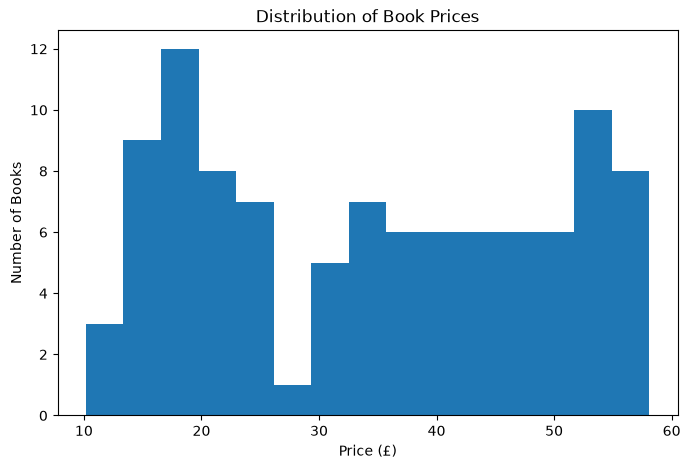

In [27]:
plt.figure(figsize=(8, 5))

plt.hist(df["Price"], bins=15)

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.show()

In [29]:
print(df["Rating"].value_counts(dropna=False))

Rating
NaN    100
Name: count, dtype: int64


In [30]:
print(df["Rating"].head(20))

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
Name: Rating, dtype: float64


In [31]:
print(df["Rating"].unique())

[nan]


In [32]:
all_books = []

rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

for page in range(1, 6):
    url = f"https://books.toscrape.com/catalogue/page-{page}.html"

    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    books = soup.select("article.product_pod")

    for book in books:
        title = book.h3.a["title"]
        price = book.select_one(".price_color").text.strip()
        availability = book.select_one(".availability").text.strip()

        rating_class = book.select_one("p.star-rating")["class"]
        rating_text = rating_class[1]
        rating = rating_map.get(rating_text)

        all_books.append({
            "Title": title,
            "Price": price,
            "Availability": availability,
            "Rating": rating
        })

df = pd.DataFrame(all_books)

df["Price"] = (
    df["Price"]
    .str.replace("£", "", regex=False)
    .str.replace("Â", "", regex=False)
    .str.strip()
    .astype(float)
)

print("Books scraped:", len(df))
print("\nRating values:")
print(df["Rating"].value_counts().sort_index())

Books scraped: 100

Rating values:
Rating
1    22
2    19
3    22
4    18
5    19
Name: count, dtype: int64


## Visualization 2: Rating Distribution

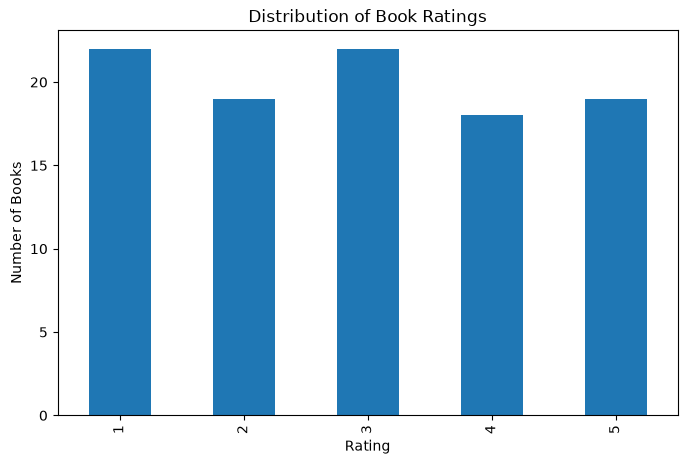

In [33]:
plt.figure(figsize=(8, 5))

df["Rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.show()

In [34]:
avg_price_by_rating = df.groupby("Rating")["Price"].mean()

print(avg_price_by_rating)

Rating
1    35.519545
2    35.909474
3    36.839091
4    33.981667
5    30.012105
Name: Price, dtype: float64


In [35]:
correlation = df["Price"].corr(df["Rating"])

print("Correlation between Price and Rating:", correlation)

Correlation between Price and Rating: -0.12174127007413635


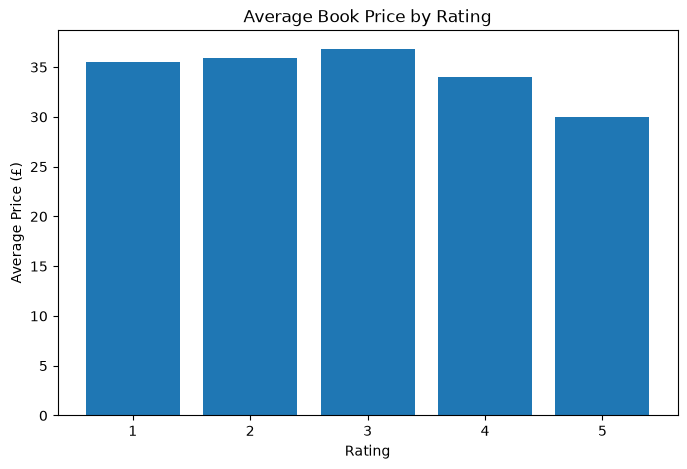

In [36]:
plt.figure(figsize=(8, 5))

plt.bar(
    avg_price_by_rating.index,
    avg_price_by_rating.values
)

plt.title("Average Book Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price (£)")
plt.xticks([1, 2, 3, 4, 5])

plt.show()

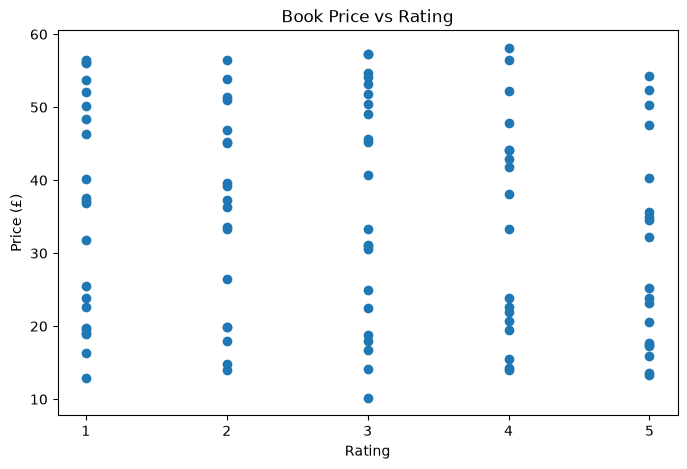

In [37]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Rating"], df["Price"])

plt.title("Book Price vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.xticks([1, 2, 3, 4, 5])

plt.show()

In [38]:
top_10_expensive = df.sort_values(
    by="Price",
    ascending=False
).head(10)

print(top_10_expensive[["Title", "Price", "Rating"]])

                                                Title  Price  Rating
68       The Death of Humanity: and the Case for Life  58.11       4
40                     Slow States of Collapse: Poems  57.31       3
15  Our Band Could Be Your Life: Scenes from the A...  57.25       3
58                                The Past Never Ends  56.50       4
57  The Pioneer Woman Cooks: Dinnertime: Comfort C...  56.41       1
91                                  Masks and Shadows  56.40       2
56                    The Secret of Dreadwillow Carse  56.13       1
67  The Electric Pencil: Drawings from Inside Stat...  56.06       1
25                      Birdsong: A Story in Pictures  54.64       3
4               Sapiens: A Brief History of Humankind  54.23       5


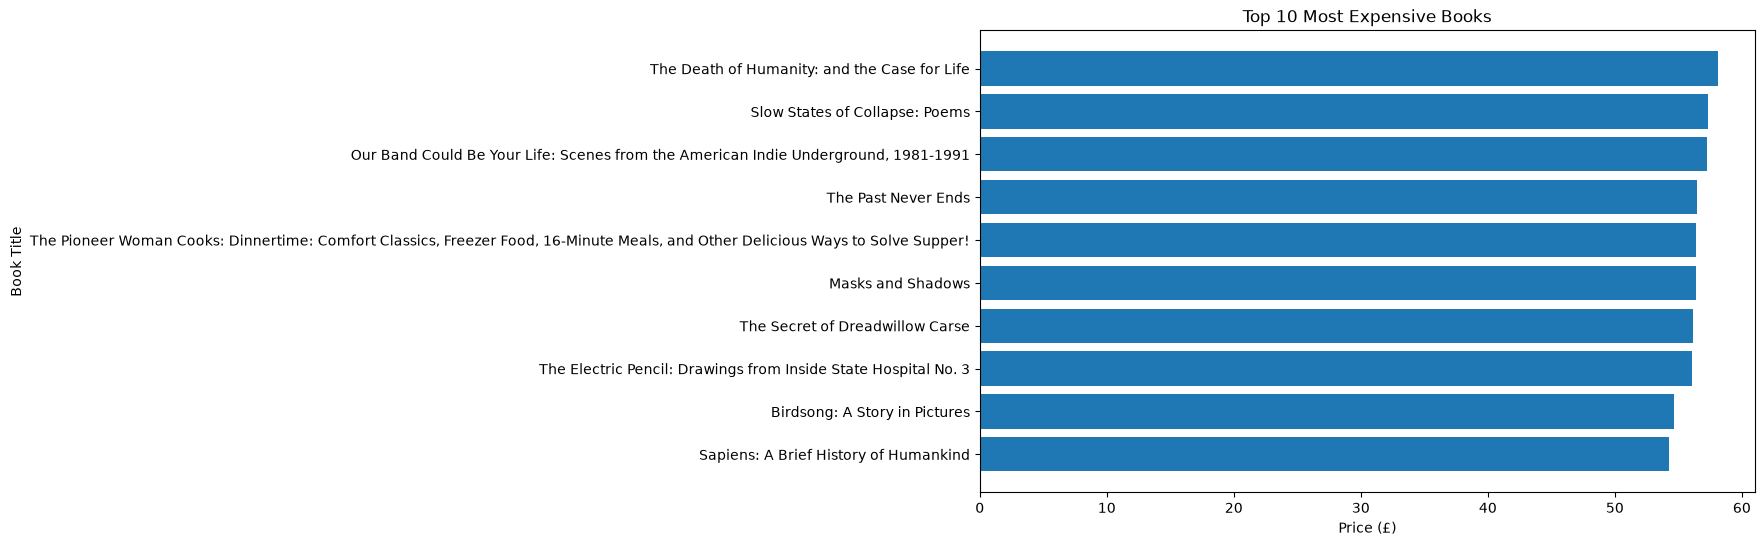

In [39]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_expensive["Title"],
    top_10_expensive["Price"]
)

plt.title("Top 10 Most Expensive Books")
plt.xlabel("Price (£)")
plt.ylabel("Book Title")

plt.gca().invert_yaxis()

plt.show()

In [40]:
df.to_csv("scraped_books.csv", index=False)

df.to_excel("scraped_books.xlsx", index=False)

print("Data exported successfully!")

Data exported successfully!


In [41]:
print(df.head())
print("\nShape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

                                   Title  Price Availability  Rating
0                   A Light in the Attic  51.77     In stock       3
1                     Tipping the Velvet  53.74     In stock       1
2                             Soumission  50.10     In stock       1
3                          Sharp Objects  47.82     In stock       4
4  Sapiens: A Brief History of Humankind  54.23     In stock       5

Shape: (100, 4)

Missing values:
Title           0
Price           0
Availability    0
Rating          0
dtype: int64
